In [1]:
!pip install shap lime scikit-learn pandas matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings('ignore')
np.random.seed(42)
shap.initjs()

print("Libraries loaded successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Libraries loaded successfully.


In [5]:
from google.colab import files

uploaded = files.upload()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [6]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

df.drop("Loan_ID", axis=1, inplace=True)
df.dropna(inplace=True)

df['Gender'] = df['Gender'].map({'Male':1,'Female':0})
df['Married'] = df['Married'].map({'Yes':1,'No':0})
df['Education'] = df['Education'].map({'Graduate':1,'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1,'No':0})

df['Property_Area'] = df['Property_Area'].map({
    'Urban':0,
    'Semiurban':1,
    'Rural':2
})

df['Loan_Status'] = df['Loan_Status'].map({
    'Y':1,
    'N':0
})

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (480, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,2,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,0,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,0,1


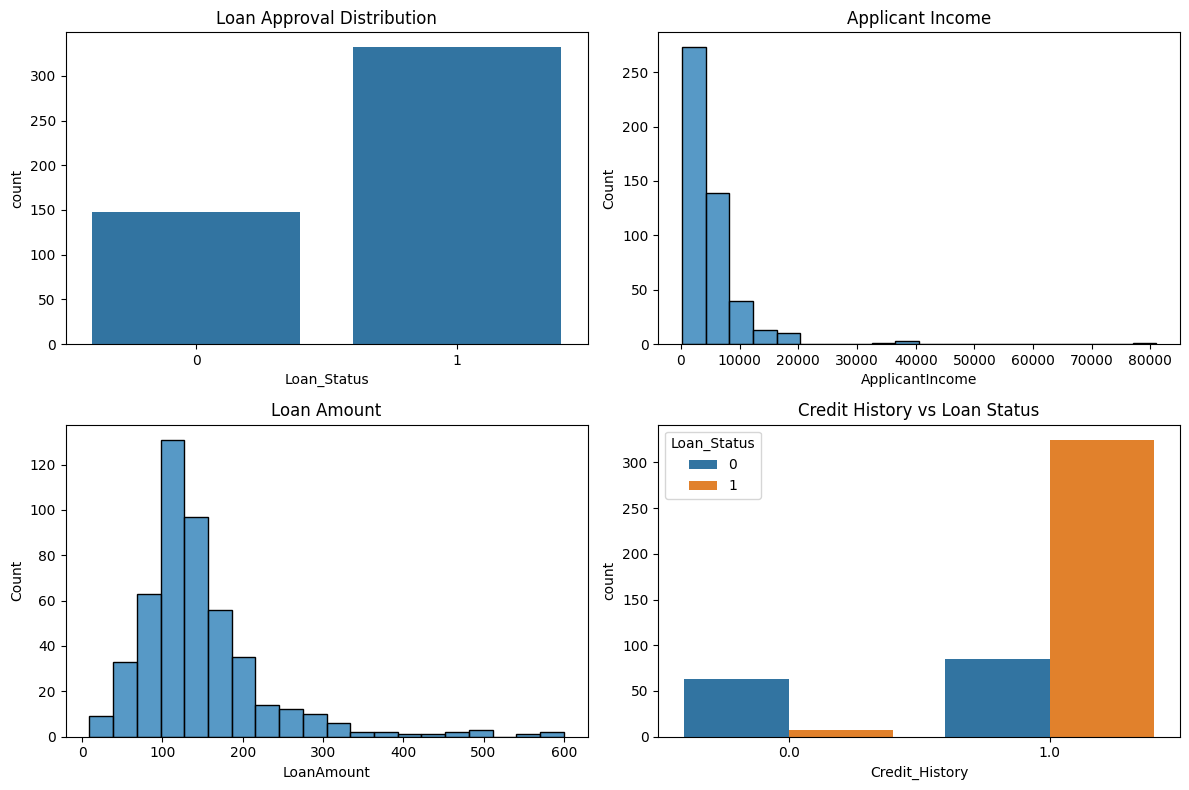

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.countplot(x='Loan_Status', data=df, ax=axes[0,0])
axes[0,0].set_title("Loan Approval Distribution")

sns.histplot(df['ApplicantIncome'], bins=20, ax=axes[0,1])
axes[0,1].set_title("Applicant Income")

sns.histplot(df['LoanAmount'], bins=20, ax=axes[1,0])
axes[1,0].set_title("Loan Amount")

sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df,
    ax=axes[1,1]
)
axes[1,1].set_title("Credit History vs Loan Status")

plt.tight_layout()
plt.show()

In [8]:
feature_names = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    'Property_Area'
]

X = df[feature_names].values
y = df['Loan_Status'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print(f"\nAccuracy: {acc:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Rejected', 'Approved']
    )
)

Training samples: 384
Testing samples : 96

Accuracy: 0.8125

Classification Report:

              precision    recall  f1-score   support

    Rejected       0.70      0.70      0.70        30
    Approved       0.86      0.86      0.86        66

    accuracy                           0.81        96
   macro avg       0.78      0.78      0.78        96
weighted avg       0.81      0.81      0.81        96



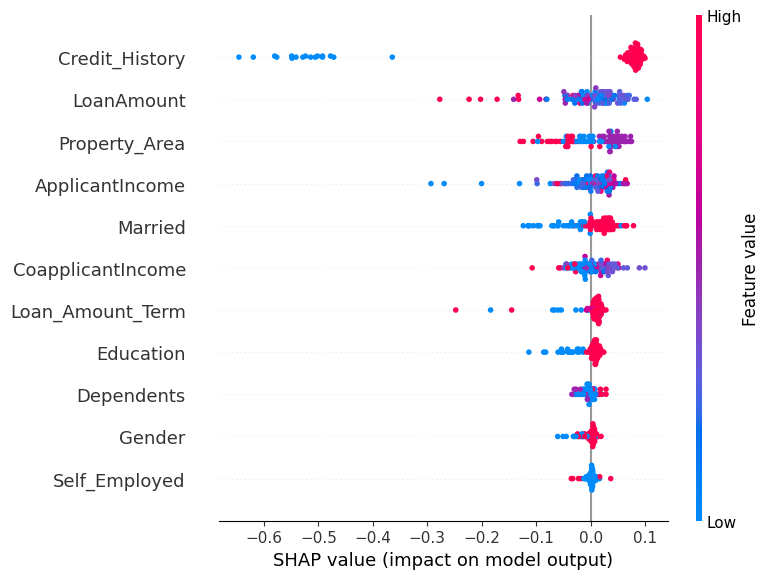

In [9]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=feature_names
)

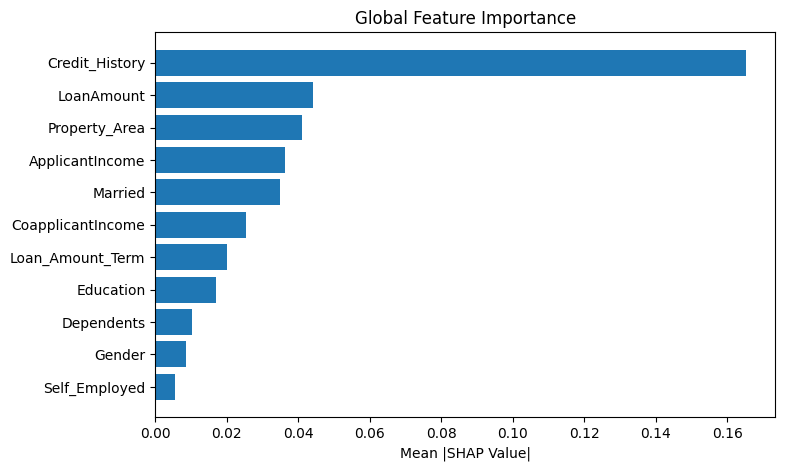

In [10]:
mean_shap = np.abs(
    shap_values[:, :, 1]
).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': mean_shap
})

importance_df = importance_df.sort_values(
    'Mean_SHAP',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Mean_SHAP']
)

plt.xlabel("Mean |SHAP Value|")
plt.title("Global Feature Importance")

plt.show()

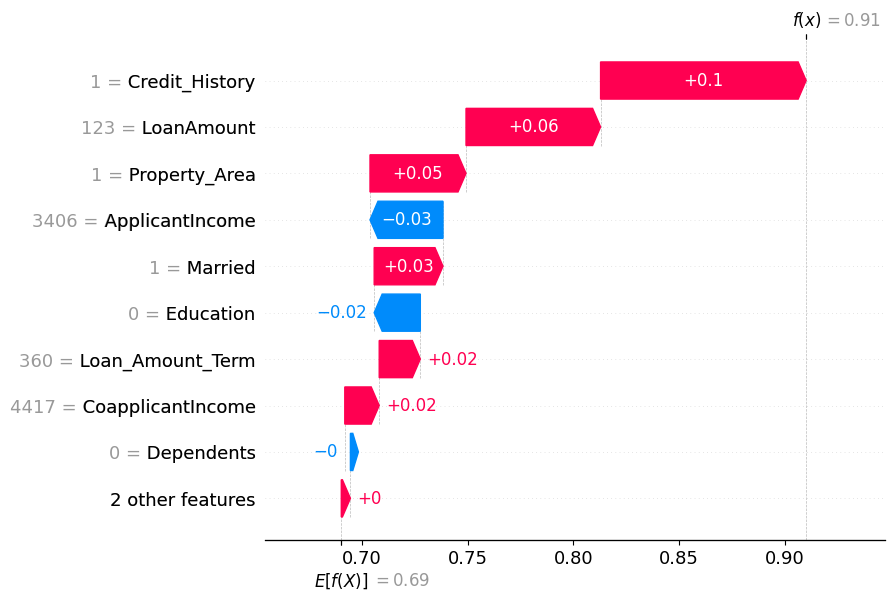

In [11]:
patient_idx = 0

patient_shap = shap_values[
    patient_idx,
    :,
    1
]

shap.plots.waterfall(
    shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value[1],
        data=X_test[patient_idx],
        feature_names=feature_names
    )
)

In [12]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['Rejected','Approved'],
    mode='classification',
    random_state=42
)

lime_exp = lime_explainer.explain_instance(
    X_test[patient_idx],
    model.predict_proba,
    num_features=8
)

lime_exp.show_in_notebook()